In [31]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager, rc

font_path = ("./data/malgun.ttf")
font_name = font_manager.FontProperties(fname=font_path).get_name()
rc("font", family=font_name)

df = pd.read_excel("./data/시도별_전출입_인구수.xlsx", header=0)

print(df.head())


   전출지별   전입지별      1970      1971      1972      1973      1974      1975  \
0  전출지별   전입지별  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1    전국     전국   4046536   4210164   3687938   4860418   5297969   9011440   
2   NaN  서울특별시   1742813   1671705   1349333   1831858   2050392   3396662   
3   NaN  부산광역시    448577    389797    362202    482061    680984    805979   
4   NaN  대구광역시         -         -         -         -         -         -   

       1976      1977  ...      2008      2009      2010      2011      2012  \
0  이동자수 (명)  이동자수 (명)  ...  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1   6773250   7397623  ...   8808256   8487275   8226594   8127195   7506691   
2   2756510   2893403  ...   2025358   1873188   1733015   1721748   1555281   
3    724664    785117  ...    514502    519310    519334    508043    461042   
4         -         -  ...    409938    398626    370817    370563    348642   

       2013      2014      2015      2016      201

In [13]:
df = df.ffill()
print(df.head())

   전출지별   전입지별      1970      1971      1972      1973      1974      1975  \
0  전출지별   전입지별  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1    전국     전국   4046536   4210164   3687938   4860418   5297969   9011440   
2    전국  서울특별시   1742813   1671705   1349333   1831858   2050392   3396662   
3    전국  부산광역시    448577    389797    362202    482061    680984    805979   
4    전국  대구광역시         -         -         -         -         -         -   

       1976      1977  ...      2008      2009      2010      2011      2012  \
0  이동자수 (명)  이동자수 (명)  ...  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)  이동자수 (명)   
1   6773250   7397623  ...   8808256   8487275   8226594   8127195   7506691   
2   2756510   2893403  ...   2025358   1873188   1733015   1721748   1555281   
3    724664    785117  ...    514502    519310    519334    508043    461042   
4         -         -  ...    409938    398626    370817    370563    348642   

       2013      2014      2015      2016      201

In [14]:
mask = (df['전출지별'] == '대구광역시') & (df['전입지별'] != '대구광역시') 
df_daegu = df[mask]
df_daegu = df_daegu.drop(['전출지별'], axis=1)
df_daegu = df_daegu.rename({'전입지별':'전입지'}, axis=1)
df_daegu = df_daegu.set_index('전입지')
print(df_daegu.head())

      1970 1971 1972 1973 1974 1975 1976 1977 1978 1979  ...    2008    2009  \
전입지                                                      ...                   
전국       -    -    -    -    -    -    -    -    -    -  ...  422676  411288   
서울특별시    -    -    -    -    -    -    -    -    -    -  ...   14824   15469   
부산광역시    -    -    -    -    -    -    -    -    -    -  ...    5066    5207   
인천광역시    -    -    -    -    -    -    -    -    -    -  ...    2125    2003   
광주광역시    -    -    -    -    -    -    -    -    -    -  ...     563     624   

         2010    2011    2012    2013    2014    2015    2016    2017  
전입지                                                                    
전국     382657  383310  359206  363224  365739  364364  337488  333118  
서울특별시   13915   13310   13838   13673   13735   13038   12802   13011  
부산광역시    5050    4906    5216    5543    6157    5182    4860    4840  
인천광역시    1968    2000    1979    2202    2015    1987    1962    1930  
광주광역시  

In [18]:
sr_one = df_daegu.loc["서울특별시"]
sr_one.head(15)

1970        -
1971        -
1972        -
1973        -
1974        -
1975        -
1976        -
1977        -
1978        -
1979        -
1980        -
1981    19760
1982    23725
1983    32205
1984    28897
Name: 서울특별시, dtype: object

In [29]:
sr_one = sr_one["1970":].replace("-", 0)
print(sr_one.head(15))
print(sr_one.shape)


1970        0
1971        0
1972        0
1973        0
1974        0
1975        0
1976        0
1977        0
1978        0
1979        0
1980        0
1981    19760
1982    23725
1983    32205
1984    28897
Name: 서울특별시, dtype: object
(48,)


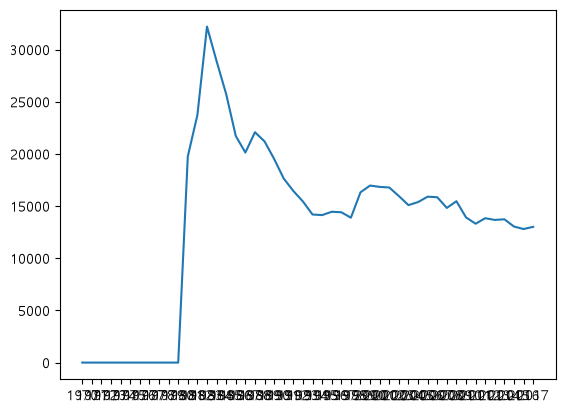

In [32]:
plt.plot(sr_one)
plt.show()

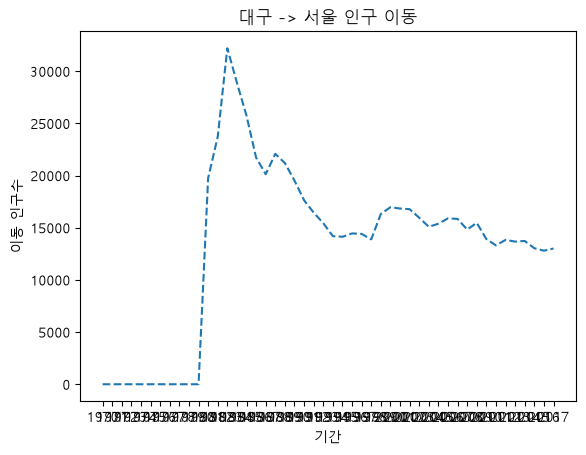

In [33]:
plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("대구 -> 서울 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.show()

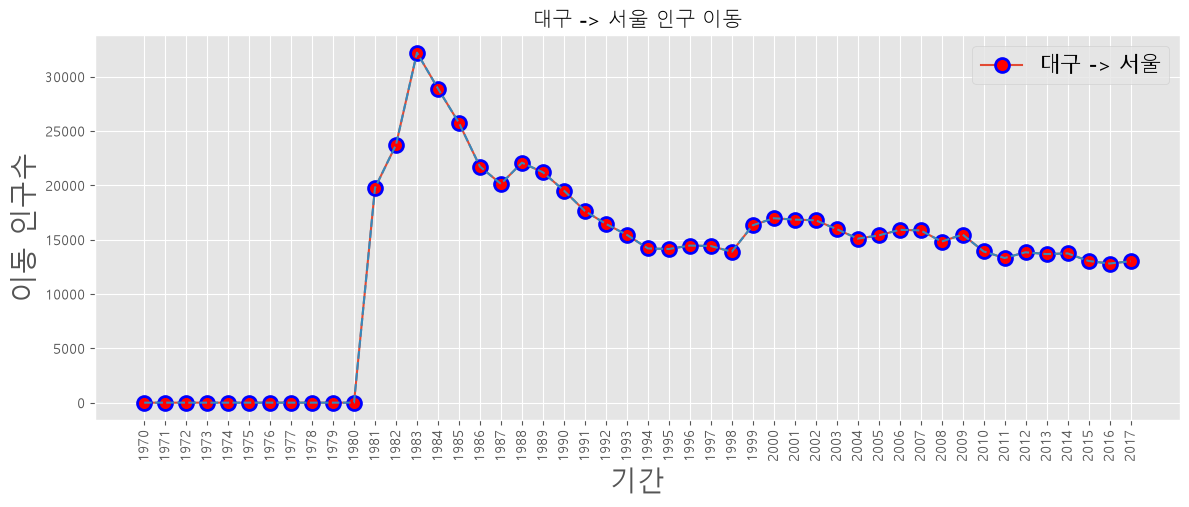

In [34]:
plt.style.use("ggplot")

plt.figure(figsize=(14, 5))

plt.xticks(size=10, rotation="vertical")
plt.plot(
    sr_one.index, sr_one.values,
    marker="o",
    markerfacecolor="red",
    markeredgecolor="blue",
    markeredgewidth=2,
    markersize=10
)

plt.plot(sr_one.index, sr_one.values, linestyle="--")

plt.title("대구 -> 서울 인구 이동")
plt.xlabel("기간", size=20)
plt.ylabel("이동 인구수", size=20)

plt.legend(labels=["대구 -> 서울"], loc="best", fontsize=15)


plt.show()

In [35]:
sr_one2 = df_daegu.loc["경상북도"]
sr_one2.head(15)

1970        -
1971        -
1972        -
1973        -
1974        -
1975        -
1976        -
1977        -
1978        -
1979        -
1980        -
1981    70840
1982    58430
1983    63729
1984    57719
Name: 경상북도, dtype: object

In [37]:
sr_one2 = sr_one2["1970":].replace("-", 0)
print(sr_one2.head(15))
print(sr_one2.shape)

1970        0
1971        0
1972        0
1973        0
1974        0
1975        0
1976        0
1977        0
1978        0
1979        0
1980        0
1981    70840
1982    58430
1983    63729
1984    57719
Name: 경상북도, dtype: object
(48,)


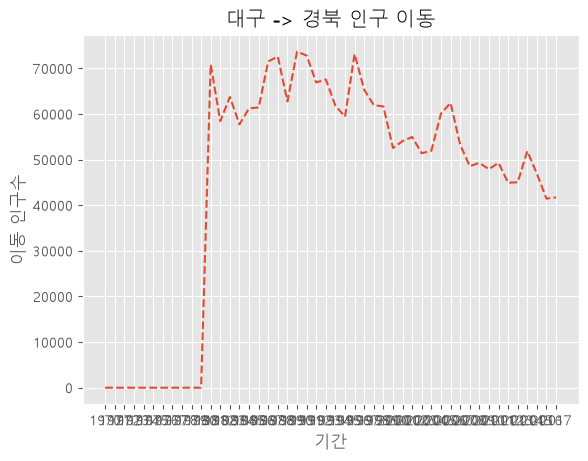

In [41]:
plt.plot(sr_one2.index, sr_one2.values, linestyle="--")

plt.title("대구 -> 경북 인구 이동")
plt.xlabel("기간")
plt.ylabel("이동 인구수")

plt.show()

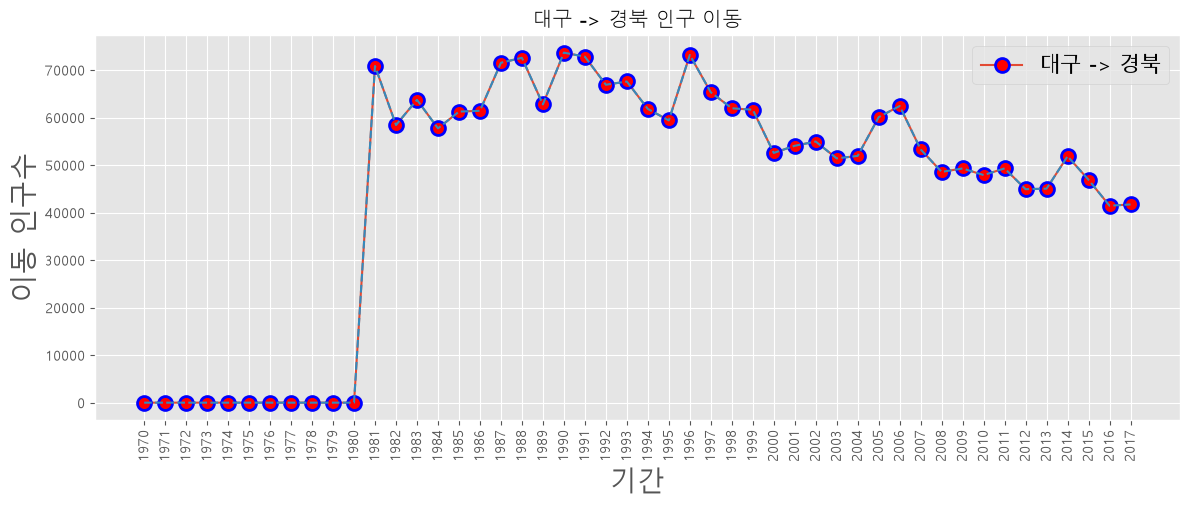

In [42]:
plt.style.use("ggplot")

plt.figure(figsize=(14, 5))

plt.xticks(size=10, rotation="vertical")
plt.plot(
    sr_one2.index, sr_one2.values,
    marker="o",
    markerfacecolor="red",
    markeredgecolor="blue",
    markeredgewidth=2,
    markersize=10
)

plt.plot(sr_one2.index, sr_one2.values, linestyle="--")

plt.title("대구 -> 경북 인구 이동")
plt.xlabel("기간", size=20)
plt.ylabel("이동 인구수", size=20)

plt.legend(labels=["대구 -> 경북"], loc="best", fontsize=15)


plt.show()